In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [7]:
import pandas as pd

df = pd.read_csv(
    "IBM-Tableau-Dashboard/IBM-HR-Attrition.csv"
)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [ ]:
#No missing values were found.

In [13]:
df['AttritionFlag'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})
df[['Attrition','AttritionFlag']].head()

,Attrition,AttritionFlag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [15]:
total_employees = len(df)

print(total_employees)

1470


In [17]:
employees_left = len(df[df['Attrition']=='Yes'])

print(employees_left)

237


In [19]:
attrition_rate = (
    employees_left /
    total_employees
)*100

print(round(attrition_rate,2))

16.12


In [21]:
dept = df.groupby('Department')['AttritionFlag'].mean()*100

dept.sort_values(ascending=False)

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: AttritionFlag, dtype: float64

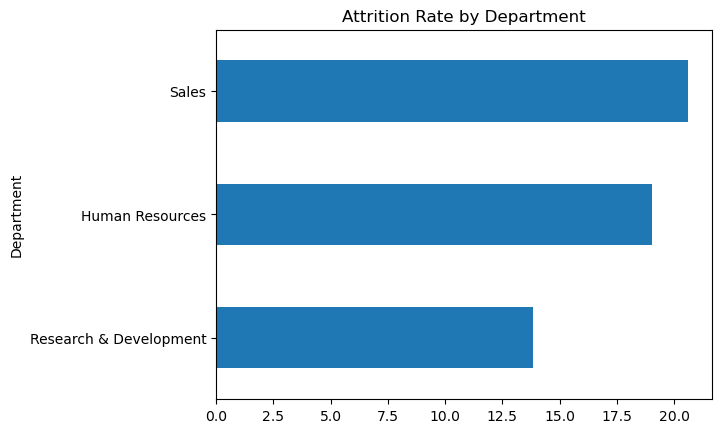

In [28]:
dept.sort_values().plot(
    kind='barh'
)

plt.title('Attrition Rate by Department')
plt.show()

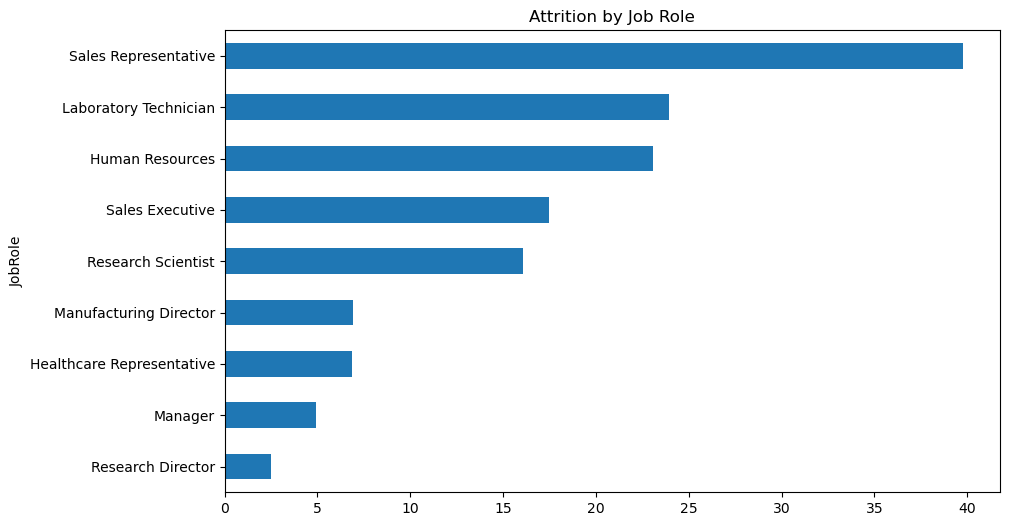

In [30]:
role = (
    df.groupby('JobRole')
    ['AttritionFlag']
    .mean()*100
)

role.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Attrition by Job Role')

plt.show()

In [32]:
overtime = (
    df.groupby('OverTime')
    ['AttritionFlag']
    .mean()*100
)

print(overtime)

OverTime
No     10.436433
Yes    30.528846
Name: AttritionFlag, dtype: float64


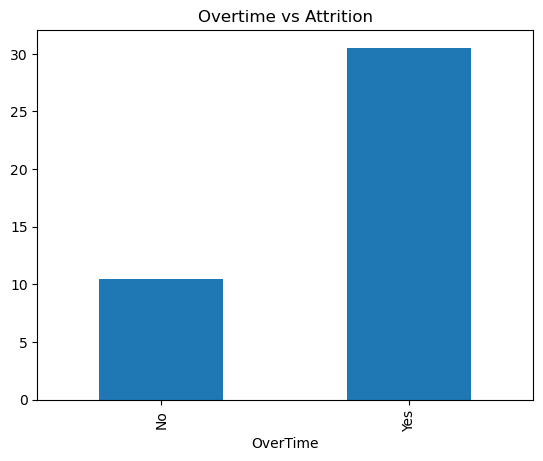

In [34]:
overtime.plot(
    kind='bar'
)

plt.title('Overtime vs Attrition')

plt.show()

In [ ]:
#Employees working overtime are significantly more likely to leave.

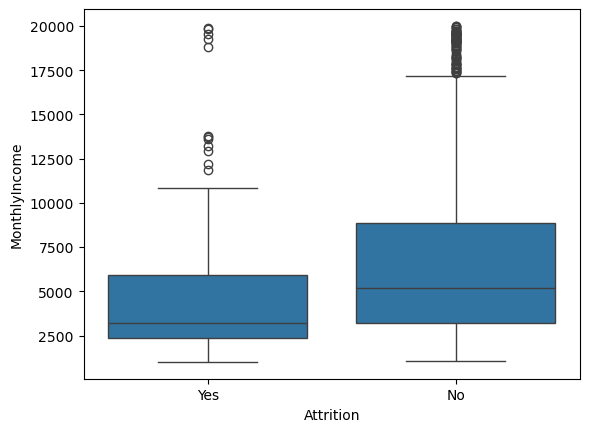

In [36]:
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.show()

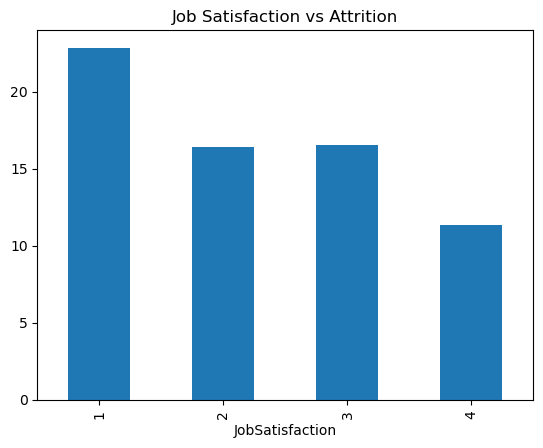

In [38]:
satisfaction = (
    df.groupby('JobSatisfaction')
    ['AttritionFlag']
    .mean()*100
)

satisfaction.plot(kind='bar')

plt.title('Job Satisfaction vs Attrition')

plt.show()

In [40]:
bins=[18,25,35,45,55,65]

labels=[
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '55+'
]

df['AgeGroup']=pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

/var/folders/2l/gwmldcgd4ksgs5cl7p72vc4r0000gn/T/ipykernel_4402/1177409215.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')


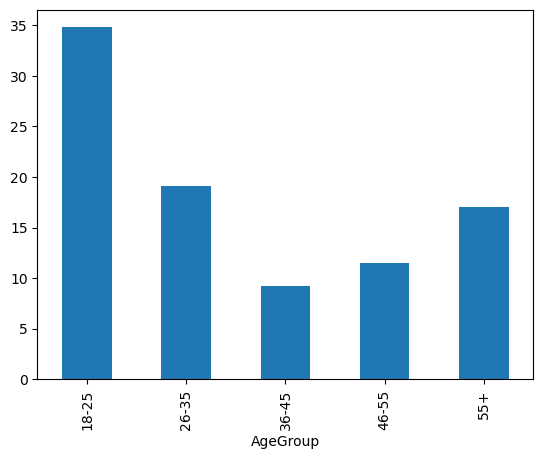

In [42]:
age = (
    df.groupby('AgeGroup')
    ['AttritionFlag']
    .mean()*100
)

age.plot(kind='bar')

plt.show()

In [48]:
df.to_csv(
    'IBM_HR_Cleaned.csv',
    index=False
)